In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

# k-Nearest Neighbor Classifier

In [2]:
data = pd.read_csv("heart.csv")
data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [3]:
data.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


## Minimal Viable Example (2 features, for visualization)

In [4]:
X = data.loc[:, ["Age", "Cholesterol"]]
y = data.iloc[:, -1]
X.head()

,Age,Cholesterol
0,40,289
1,49,180
2,37,283
3,48,214
4,54,195


In [5]:
# TODO: Apply the train_test_split function to split the data into training and test sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.3, random_state = 42)
print("Test set size:", X_test.shape[0])

Test set size: 276


In [6]:
# Most important: n_neighbors and metric (default: minkowski with p=2, i.e., Euclidean distance)
# Minkowski distance = sum(|x_i - y_i|^p)^(1/p)
# TODO: Instantiate a kNN Classifier with k=5 and fit it to the data
knn = KNeighborsClassifier(n_neighbors= 5)
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


              precision    recall  f1-score   support

           0       0.53      0.56      0.55       112
           1       0.69      0.66      0.68       164

    accuracy                           0.62       276
   macro avg       0.61      0.61      0.61       276
weighted avg       0.63      0.62      0.62       276



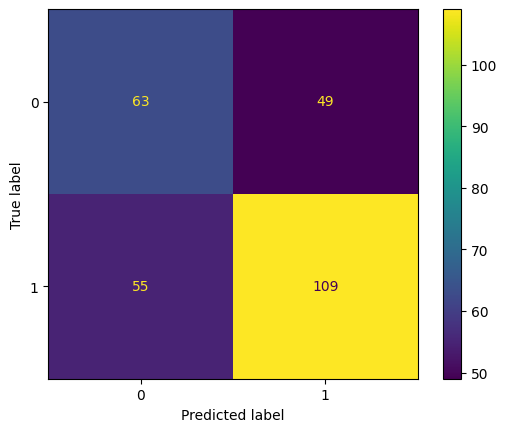

In [7]:
y_pred = knn.predict(X_test)

print(classification_report(y_test, y_pred))
# Introducing confusion matrix: We also see what exactly our mispredictions are
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

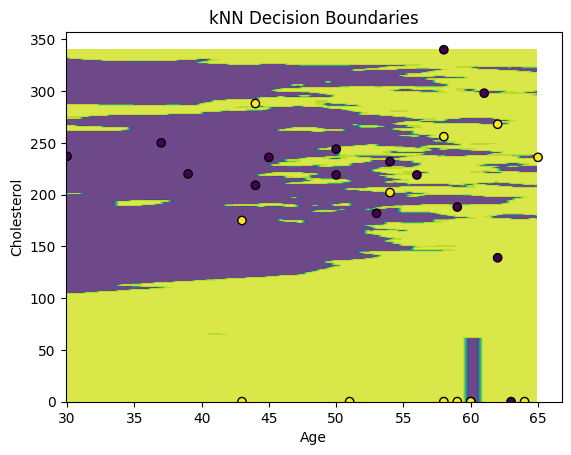

In [8]:
# Try out every possible point of age/cholesterol and color the background
def plot_decision_boundaries(X, y, model, h=0.02, padding_x=0.1, padding_y=0.1, downsample=0.1):
    # 1. Downsample X and y simultaneously using shared indices
    sample_indices = X.sample(frac=downsample, random_state=1337).index
    X_sub = X.loc[sample_indices]
    y_sub = y.loc[sample_indices]

    x_min, x_max = X_sub.iloc[:, 0].min() - padding_x, X_sub.iloc[:, 0].max() + padding_x
    y_min, y_max = X_sub.iloc[:, 1].min() - padding_y, X_sub.iloc[:, 1].max() + padding_y
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    # 2. Reconstruct DataFrame for predictions to suppress sklearn feature name warnings
    grid_points = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=X.columns)
    Z = model.predict(grid_points)
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.8)
    
    # 3. Map the subsetted labels (y_sub) to the subsetted coordinates (X_sub)
    plt.scatter(X_sub.iloc[:, 0], X_sub.iloc[:, 1], c=y_sub, edgecolors='k', marker='o')
    plt.xlabel(X.columns.values[0])
    plt.ylabel(X.columns.values[1])
    plt.title("kNN Decision Boundaries")

# Example call
plot_decision_boundaries(X_test, y_test, knn, h=0.5)

In [9]:
# As visible above, the main differences take place on the y-axis.
# Looking back at the blackboard formula, we can see that Cholesterol (due to its higher range) has a much higher influence.
# TODO: Apply feature scaling to the X_train and X_test using a 
from sklearn import set_config
set_config(transform_output = "pandas")

sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

In [10]:
X_train_scaled.head()

,Age,Cholesterol
712,0.464714,0.294989
477,0.781767,-1.905390
409,-0.063707,-1.905390
448,0.993136,0.257376
838,0.993136,1.197709


In [11]:
# TODO: Refit the model with proper scaling
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


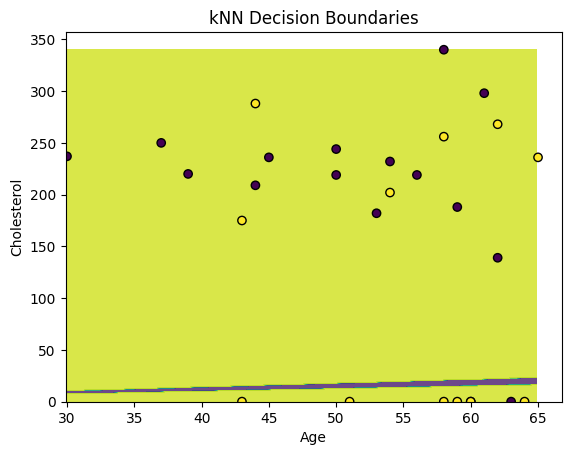

In [12]:
# example call 
plot_decision_boundaries(X_test, y_test, knn, h=0.5)

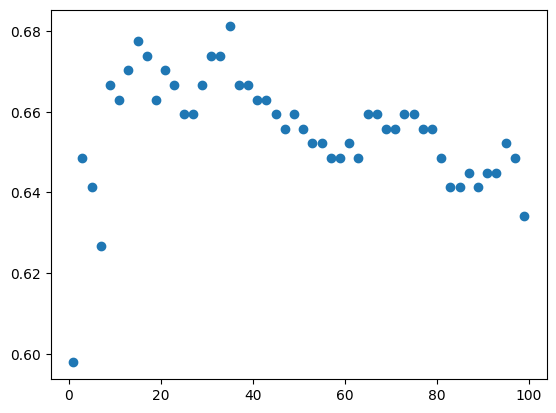

In [13]:
# Try to find out the best k for our dataset by plotting the accuracy for different k's
# There are better (automated) ways to do this, but for the start it is easy to understand, and we'll be discussing the alternative soon!
# Question: Is it problematic to use the test set for this?
# TODO: Write loop that trains a kNN model for each odd k and stores best accuracy in a list

n_params = 101

result = []
xs = range(1,100,2)
for i in xs:
    knn_model = KNeighborsClassifier(n_neighbors=i)
    knn_model.fit(X_train_scaled, y_train)

    acc = accuracy_score(y_test, knn_model.predict(X_test_scaled))
    result.append(acc)

plt.scatter(xs, result)

## Using all features

In [14]:
X = data.iloc[:, :-1]
y = data.iloc[:, -1]
print(X.shape)
X.head()

(918, 11)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up


In [15]:
# Quick and dirty categorical encoding
# drop_first = remove collinear features (e.g., Sex=F automatically implies Sex!=M) --> this is actually necessary for some algorithms!
X_dummy = pd.get_dummies(X, columns=['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], drop_first=True, dtype=int)
X_dummy.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1.0,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0.0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1.5,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0.0,1,0,1,0,1,0,0,0,1


In [20]:
# TODO: Dataset partitioning (70/30)
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split (X_dummy ,y, test_size = 0.3, random_state = 42)
print("Test set size:", X_test.shape[0])
print("Train set size:", X_train_full.shape)
print("Test set size:", X_test_full.shape)

Test set size: 276
Train set size: (642, 15)
Test set size: (276, 15)


In [21]:
# TODO: Apply scaling
sc = StandardScaler()
X_train_full_scaled = sc.fit_transform(X_train_full)
X_test_full_scaled = sc.transform(X_test_full)

In [22]:
# TODO: Fit the new model on scaled data with arbitrary n_neighbors
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_full_scaled, y_train_full)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


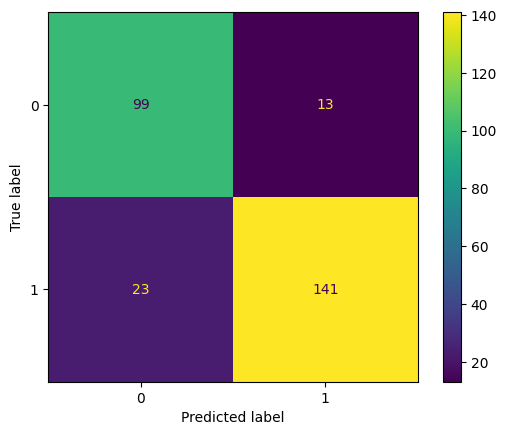

In [23]:
# TODO: Evaluate the model using the classification_report and ConfusionMatrixDisplay methods/classes
y_pred = knn.predict(X_test_full_scaled)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

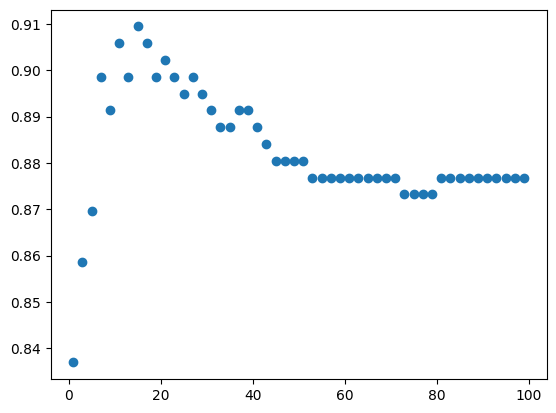

In [24]:
# Try to find out the best k for our dataset by plotting the accuracy for different k's
# There are better (automated) ways to do this, but for the start it is easy to understand, and we'll be discussing the alternative soon!
# Question: Is it problematic to use the test set for this?
# TODO: Calculate and save in a loop (you can copy this from above)
n_params = 101

result = []
xs = range(1,100,2)
for i in xs:
    knn_model = KNeighborsClassifier(n_neighbors=i)
    knn_model.fit(X_train_full_scaled, y_train_full)
    
    acc = accuracy_score(y_test_full, knn_model.predict(X_test_full_scaled))
    result.append(acc)

plt.scatter(xs, result)

## Noisy Features

This is actually well distributed data. What happens if we add some noise:
1) To the data? (additional features)
2) To the labels? (random flip)

In [25]:
# Set seed so we get the same "random" result everytime
np.random.seed(43)

# Generate noisy columns
num_noise_features = 100
noise_matrix = np.random.normal(0, 1, size=(len(X_dummy), num_noise_features))
noise_df = pd.DataFrame(noise_matrix, columns=[f"Noisy_{i}" for i in range(num_noise_features)], index=X_dummy.index)

# Concatenate to create the noisy training set
X_noisy = pd.concat([X_dummy, noise_df], axis=1)

X_noisy.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,...,Noisy_90,Noisy_91,Noisy_92,Noisy_93,Noisy_94,Noisy_95,Noisy_96,Noisy_97,Noisy_98,Noisy_99
0,40,140,289,0,172,0.0,1,1,0,0,...,-1.163702,0.568939,-0.462644,0.287355,-0.977339,-0.222436,0.096932,-0.188384,1.591602,0.585811
1,49,160,180,0,156,1.0,0,0,1,0,...,-0.186985,0.823932,2.015498,-1.031448,-0.067518,-0.025382,0.205293,-1.223640,0.467430,0.036701
2,37,130,283,0,98,0.0,1,1,0,0,...,-0.475298,-1.019481,0.555473,-1.048394,0.538878,0.678812,-1.503688,-0.472396,0.909275,0.157828
3,48,138,214,0,108,1.5,0,0,0,0,...,-2.158655,0.553622,0.107561,-0.527853,-0.510177,0.585798,0.291448,-1.010566,-1.088963,0.110536
4,54,150,195,0,122,0.0,1,0,1,0,...,1.256776,2.319182,0.399550,-1.931095,-1.253721,0.549800,0.379980,-2.129703,0.519211,0.645047


In [26]:
X_noisy_train, X_noisy_test, y_train, y_test = train_test_split(X_noisy, y, test_size=0.3, random_state=42)

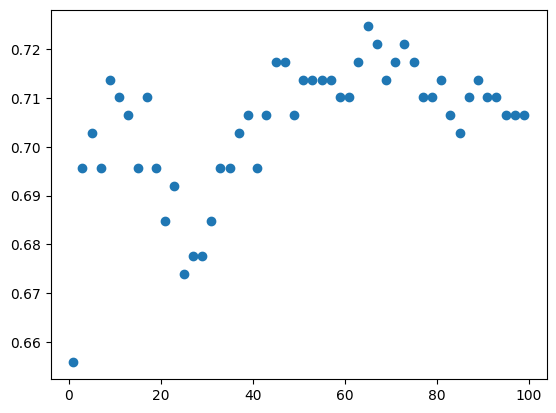

In [27]:
num_elements = 101

results = []
for k in range(1, num_elements, 2):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_noisy_train, y_train)

    y_pred = knn.predict(X_noisy_test)
    results.append(accuracy_score(y_test, y_pred))

plt.scatter(range(1, num_elements, 2), results)

In [28]:
X_train, X_test, y_train_noisy, y_test = train_test_split(X_dummy, y, test_size=0.3, random_state=42)

In [29]:
# Important: we inject label noise AFTER the train-test split, otherwise we would only look at "how good are we at predicting noise"ArithmeticError
# Randomly flip labels with a chance of 20%
flip_mask = np.random.rand(len(y_train_noisy)) < 0.3
y_train_noisy[flip_mask] = 1 - y_train_noisy[flip_mask]

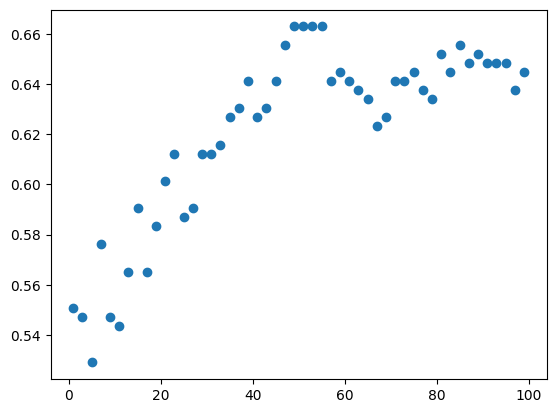

In [30]:
num_elements = 101

results = []
for k in range(1, num_elements, 2):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train_noisy)

    y_pred = knn.predict(X_test)
    results.append(accuracy_score(y_test, y_pred))

plt.scatter(range(1, num_elements, 2), results)

# Regression

In [31]:
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor

In [32]:
# Get dataset directly using sklearn
housing = fetch_california_housing(as_frame=True)
print(housing["DESCR"])

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [33]:
X = housing.data
y = housing.target

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(X_train.shape, X_test.shape)

(14448, 8) (6192, 8)


In [35]:
# Briefly change the config, to avoid standardscaler conversion issues with the dataframe
from sklearn import set_config
set_config(transform_output="pandas")

# Demonstrating the power of scaling
sc = StandardScaler()
sc.fit(X_train)
X_train = sc.transform(X_train)
X_test = sc.transform(X_test)

In [36]:
knn_reg = KNeighborsRegressor(n_neighbors=5)
knn_reg.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


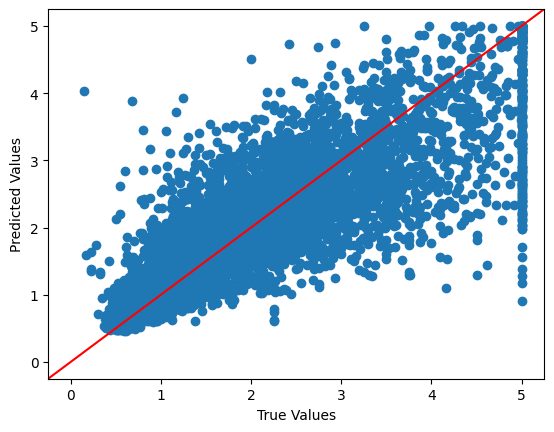

In [37]:
y_pred = knn_reg.predict(X_test)

plt.scatter(y_test, y_pred)
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.axline((0,0), (1,1), c="red")


In [38]:
# Simple explanation for R2: R2 = 1 - (MSE of our model / MSE of a naive model that always predicts the mean)
# General rule: The higher, the better. Negative values are possible, and mean that our model is worse than the naive model (just predicting the mean)
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MSE: 0.42949402014873317
R2: 0.6727764602454027


## Demonstration: Extrapolation

Take a second and think about the nature of kNN. Are these models able to extrapolate? Why/why not? How does the prediction landscape look?

In [39]:
X_train_1D = X_train[['MedInc']]
X_test_1D = X_test[['MedInc']]

In [40]:
sc_1D = StandardScaler()
X_train_1D_scaled = sc_1D.fit_transform(X_train_1D)

In [41]:
knn_1D = KNeighborsRegressor(n_neighbors=15)
knn_1D.fit(X_train_1D, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",15
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [ ]:
# TODO: Generate a synthetic axis that forces the model to predict unseen values (e.g., beyond the maximum median income)
x_synthetic = np.linspace(-2,10,500)
x_synthetic_df = pd.DataFrame(x_synthetic, columns=['MedInc'])
y_synthetic_pred = knn_1D.predict(x_synthetic_df)

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(X_train_1D_scaled[['MedInc']], y_train, alpha=0.1, label='Training Data', color='gray')
plt.plot(x_synthetic, y_synthetic_pred, color='red', linewidth=2, label='kNN Prediction (k=15)')
plt.xlabel("Median Income (Standardized)")
plt.ylabel("Median House Value (Hundreds of Thousands)")
plt.title("kNN Regressor: The Extrapolation Failure")
plt.legend()
plt.grid(True)
plt.show()